In [2]:
import pandas as pd
import numpy as np

data = pd.read_csv("train.csv")
data.info()
data.describe()
data.head()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
#columns: 12
#rows: 891
#columns with missing values: Age, Cabin, Embarked
#Categorical columns: Name, Sex, Ticket, Cabin, Embarked
#Numerical columns: PassengerId, Survived, Pclass, Age, SibSp, Parch, Fare



Summary:
This dataset has 12 columns and 891 rows. Some columns have missing values and those columns are: Age, Cabin, Embarked.
Dataset contains both Categorical and Numerical columns and they are:
    Categorical columns: Name, Sex, Ticket, Cabin, Embarked.
    Numerical columns: PassengerId, Survived, Pclass, Age, SibSp, Parch, Fare.
The Surived Column tells us if the passenger survived or not.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("train.csv")

df["Age"]=df["Age"].fillna(df["Age"].median())
df["Embarked"]=df["Embarked"].fillna(df["Embarked"].mode()[0])
df = df.drop(columns=["Cabin"])

df.info()



<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 76.7 KB


Age and Embarked were filled as Majority of the column had values which is useful however cabin column was dropped rather than dropna as that would lead to all of the rows that didnt have a value to be removed reducing the whole data from 891 rows to 204. dropping the column itself is more appropriate as the column doesnt have many values so it should not impact the result significantly.

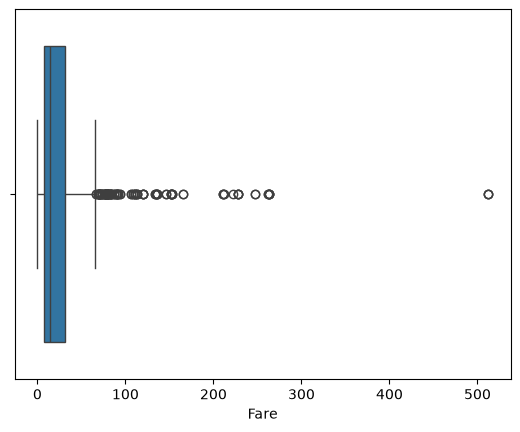

In [5]:
sns.boxplot(x=df["Fare"])
plt.show()

one outlier where fare crosses 500

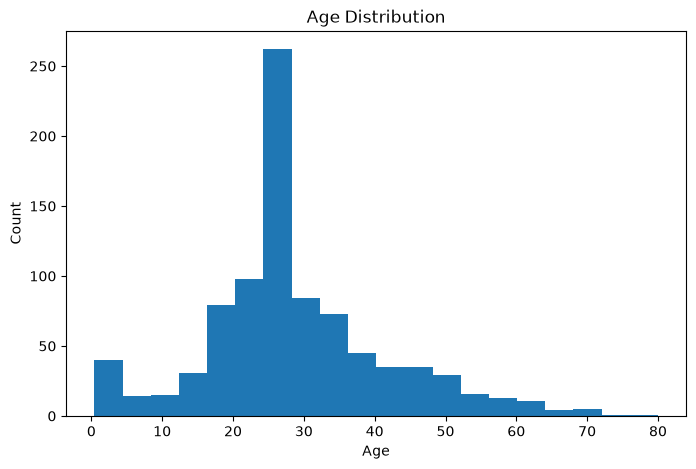

In [6]:
plt.figure(figsize=(8,5))
plt.hist(df["Age"], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

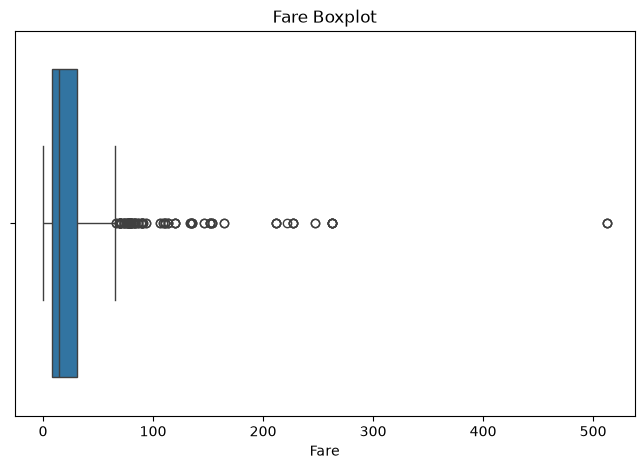

In [7]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Fare"])
plt.title("Fare Boxplot")
plt.show()

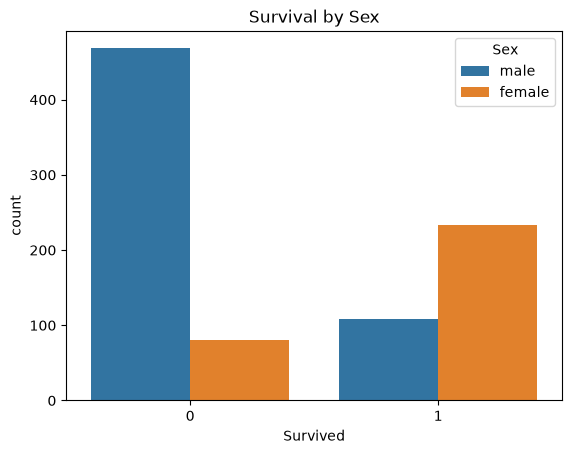

In [8]:
sns.countplot(x="Survived", hue="Sex", data=df)
plt.title("Survival by Sex")
plt.show()

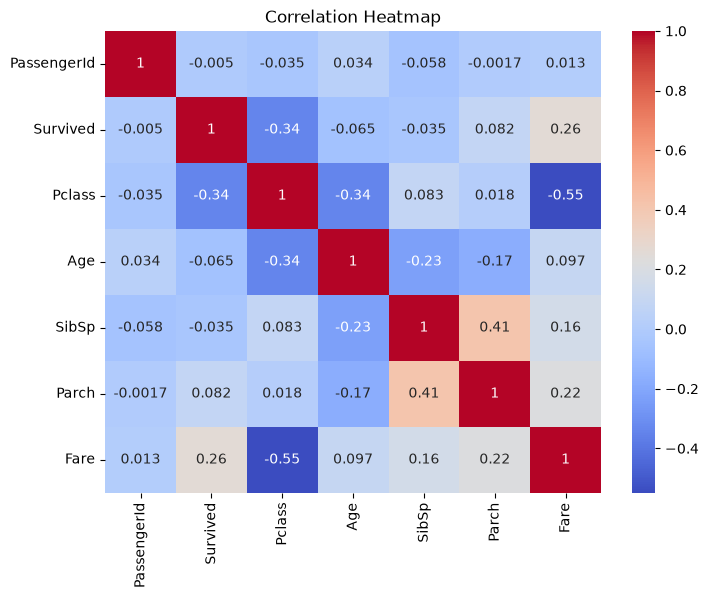

In [9]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Sex affects survival the most looking at the bar chart as more females have surived compared to males even though they are less in number. One possible explanation could be women and children are given preference in scenarios such as evacuation etc.

Week 2: task 1 

In [10]:
import sklearn as sk

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

X = df[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]]
Y = df["Survived"]

X = pd.get_dummies(X, columns=["Sex", "Embarked"], dtype=int)

X_train, X_test, Y_train, Y_test= train_test_split(X, Y, test_size=0.2, random_state=42)

model=LogisticRegression(max_iter=1000)

model.fit(X_train, Y_train)

Y_pred=model.predict(X_test)

Above code, we imported the sci-kit library and the specific modules we need such as regression model, train test split and accuracy score and confusiion matrix. Y is our target variable and X is the information we provide to the model. We use pd.getdummies because our model needs the data in numerical form so this converts all the string related columns to integers. Train test splits the data into training data and test data. Our model is trained upon training data and predictions are generated by providing the test data.

In [11]:
accuracy=accuracy_score(Y_test, Y_pred)
print("Accuracy:", accuracy*100, "%")

Accuracy: 81.00558659217877 %


In [12]:
c_matrix=confusion_matrix(Y_test, Y_pred)
print("Confusion Matrix:")
print(c_matrix)

Confusion Matrix:
[[90 15]
 [19 55]]


This represents what model predicted right and it didnt. 90 represents where both people actually died and the model predicted they died. 15 represents when people actually died but model predicted otherwise. Similarly, 55 represents when both model predicted and actual data showed people survived. 19 represents model predicted that people died but actual data said they survived

In [13]:
from sklearn.metrics import classification_report

c_report= classification_report(Y_test, Y_pred)
print("Classification Report:")
print(c_report)

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



Accuracy can be misleading when there is a large difference between each class or category in a dataset as a model can have a high accuracy predicting the major category while lacking in prediciting accurately for minor categories.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = { "C":[0.01, 0.1, 1, 10, 100], "solver":["liblinear", "lbfgs"] }
grid_search=GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5, scoring="accuracy")

grid_search.fit(X_train, Y_train)

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'C': 1, 'solver': 'liblinear'}


In [17]:
best_model=grid_search.best_estimator_
Y_pred_best=best_model.predict(X_test)

print("Best Model Accuracy:", accuracy_score(Y_test, Y_pred_best)*100, "%")
print(classification_report(Y_test, Y_pred_best))

Best Model Accuracy: 79.3296089385475 %
              precision    recall  f1-score   support

           0       0.81      0.85      0.83       105
           1       0.77      0.72      0.74        74

    accuracy                           0.79       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



| Metric    | Original |    Tuned | Change |
| --------- | -------: | -------: | -----: |
| Accuracy  | **0.81** | **0.79** | ↓ 0.02 |
| Precision | **0.79** | **0.77** | ↓ 0.02 |
| Recall    | **0.74** | **0.72** | ↓ 0.02 |
| F1-score  | **0.76** | **0.74** | ↓ 0.02 |


After tuning, the results actually dropped by 2 percents accross all metrics which shows that hyperparameter tuning does not guarantee best performance on an unseen data set

In [18]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'C': 1, 'solver': 'liblinear'}
0.7962966610853935
